## UNSW-NB15 — Simple Multi-Task Classification Pipeline

### Targets
- **`label`**: binary classification (0 = no attack, 1 = attack)
- **`attack_cat`**: multi-class classification (type of attack)

### What you’ll get
- Basic dataset exploration (types, missing values, imbalance, quick distributions)
- Simple cleaning + preprocessing (duplicates, missing values, categorical encoding)
- Minimal feature selection (drop ID-like columns, variance + correlation filtering)
- Two tuned model families compared per target (Random Forest vs Gradient Boosting)
- Clear evaluation (accuracy, precision/recall/F1, confusion matrices)
- Saved artifacts in `training/Processed_Dataset/` (processed CSV + trained models)



In [3]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

if Path("Dataset").exists():
    DATA_DIR = Path("Dataset")
    OUT_DIR = Path("Processed_Dataset")
else:
    DATA_DIR = Path("training/Dataset")
    OUT_DIR = Path("training/Processed_Dataset")

OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_ROWS_TO_LOAD = None

# Tuning can be slow on very large datasets; this keeps the demo practical.
# Set to None to train on the full dataset.
MAX_ROWS_FOR_MODELING = 500_000

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())



DATA_DIR: C:\Users\USER\Desktop\Grad project\CTD-Project-main\training\Dataset
OUT_DIR: C:\Users\USER\Desktop\Grad project\CTD-Project-main\training\Processed_Dataset


### 1) Load dataset (using the official feature list)

The `UNSW-NB15_*.csv` files are **headerless** in this folder, so we load the column names from `NUSW-NB15_features.csv` and apply them when reading each part.


In [5]:
features_path = DATA_DIR / "NUSW-NB15_features.csv"
parts = sorted(DATA_DIR.glob("UNSW-NB15_*.csv"))

assert features_path.exists(), f"Missing: {features_path}"
assert parts, f"No dataset parts found in {DATA_DIR}"

features_df = pd.read_csv(features_path, encoding='cp1252')
features_df.columns = [c.strip() for c in features_df.columns]

raw_feature_names = features_df["Name"].astype(str).tolist()
raw_feature_types = features_df["Type"].astype(str).str.strip().str.lower().tolist()

# Clean column names for easier use (and to ensure the targets are exactly 'label' and 'attack_cat')
def clean_col(name: str) -> str:
    name = name.strip().lower()
    name = "".join(ch if ch.isalnum() else "_" for ch in name)
    while "__" in name:
        name = name.replace("__", "_")
    return name.strip("_")

col_names = [clean_col(n) for n in raw_feature_names]


print("Columns (count):", len(col_names))
print("Last columns:", col_names[-3:])

# Build a simple type map from the feature metadata
# (nominal → categorical, integer/float/binary → numeric)
type_map = {}
for name, t in zip(col_names, raw_feature_types):
    if "nominal" in t:
        type_map[name] = "categorical"
    elif "int" in t or "float" in t or "binary" in t:
        type_map[name] = "numeric"
    else:
        type_map[name] = "unknown"       

Columns (count): 49
Last columns: ['ct_dst_src_ltm', 'attack_cat', 'label']


In [7]:
na_values = ["", " ", "  ", "   "]  # treat empty/blank as missing; '-' is a valid category here

dfs = []
for p in parts:
    print("Loading:", p.name)
    part_df = pd.read_csv(
        p,
        header=None,
        names=col_names,
        na_values=na_values,
        keep_default_na=True,
        low_memory=False,
        nrows=MAX_ROWS_TO_LOAD,
    )
    dfs.append(part_df)

df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns based on metadata
numeric_cols_by_meta = [c for c in col_names if type_map.get(c) == "numeric"]
cat_cols_by_meta = [c for c in col_names if type_map.get(c) == "categorical"]

for c in numeric_cols_by_meta:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep categorical as strings (helps consistent handling of missing values)
for c in cat_cols_by_meta:
    df[c] = df[c].astype("string")

print("\nDataset shape:", df.shape)
df.head()


Loading: UNSW-NB15_1.csv
Loading: UNSW-NB15_2.csv
Loading: UNSW-NB15_3.csv
Loading: UNSW-NB15_4.csv

Dataset shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390.0,149.171.126.6,53.0,udp,CON,0.001055,132,164,31,...,0.0,3,7,1,3,1,1,1,<NA>,0
1,59.166.0.0,33661.0,149.171.126.9,1024.0,udp,CON,0.036133,528,304,31,...,0.0,2,4,2,3,1,1,2,<NA>,0
2,59.166.0.6,1464.0,149.171.126.7,53.0,udp,CON,0.001119,146,178,31,...,0.0,12,8,1,2,2,1,1,<NA>,0
3,59.166.0.5,3593.0,149.171.126.5,53.0,udp,CON,0.001209,132,164,31,...,0.0,6,9,1,1,1,1,1,<NA>,0
4,59.166.0.3,49664.0,149.171.126.0,53.0,udp,CON,0.001169,146,178,31,...,0.0,7,9,1,1,1,1,1,<NA>,0


In [27]:
df.columns

Index(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
       'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload',
       'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz',
       'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime',
       'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat',
       'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login',
       'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat',
       'label'],
      dtype='object')

### 2) Quick exploration (types, missing values, duplicates, class imbalance)

We’ll keep exploration lightweight and practical:
- Verify data types
- Check missing values + duplicates
- Inspect target distributions (`label`, `attack_cat`)


In [9]:
# Data types overview
print(df.dtypes.value_counts())

# Missing values (top 20)
missing_frac = (df.isna().mean().sort_values(ascending=False))
print("\nTop missing columns:")
display(missing_frac.head(20).to_frame("missing_fraction"))

# Duplicates
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes:,} ({n_dupes / len(df):.4%})")

# Targets
print("\n'label' distribution:")
display(df["label"].value_counts(dropna=False).to_frame("count"))

print("\n'attack_cat' distribution (including missing):")
display(df["attack_cat"].value_counts(dropna=False).head(20).to_frame("count"))


int64             28
float64           15
string[python]     6
Name: count, dtype: int64

Top missing columns:


,missing_fraction
attack_cat,0.873513
is_ftp_login,0.562934
ct_ftp_cmd,0.562934
ct_flw_http_mthd,0.530756
dsport,0.000120
sport,0.000003
ct_src_dport_ltm,0.000000
ackdat,0.000000
djit,0.000000
stime,0.000000



Duplicate rows: 480,633 (18.9222%)

'label' distribution:


,count
label,
0,2218764
1,321283



'attack_cat' distribution (including missing):


,count
attack_cat,
<NA>,2218764
Generic,215481
Exploits,44525
Fuzzers,19195
DoS,16353
Reconnaissance,12228
Fuzzers,5051
Analysis,2677
Backdoor,1795


In [13]:
normal_count = (df["label"] == 0).sum()
attack_count = (df["label"] == 1).sum()

total = len(df)

print("Total samples:", total)
print("Normal traffic:", normal_count)
print("Attack traffic:", attack_count)

print("\nPercentages:")
print("Normal %:", normal_count / total * 100)
print("Attack %:", attack_count / total * 100)

Total samples: 2540047
Normal traffic: 2218764
Attack traffic: 321283

Percentages:
Normal %: 87.35129704292873
Attack %: 12.648702957071267


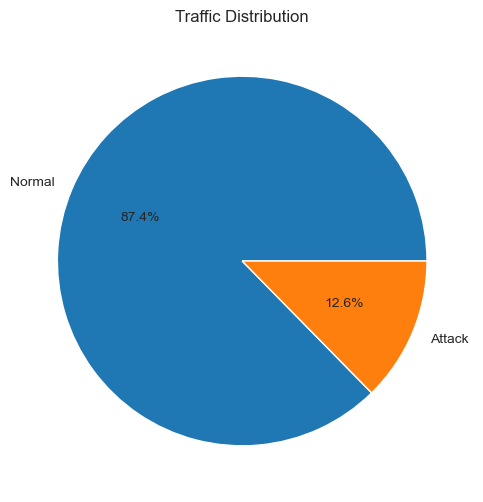

In [21]:
counts = df["label"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(counts, labels=["Normal","Attack"], autopct='%1.1f%%')

plt.title("Traffic Distribution")

plt.show()

In [29]:
print(df['ct_ftp_cmd'].value_counts(normalize=True))

ct_ftp_cmd
0.0    0.960664
1.0    0.036100
2.0    0.001139
4.0    0.000865
3.0    0.000657
6.0    0.000299
5.0    0.000261
8.0    0.000016
Name: proportion, dtype: float64


<Axes: xlabel='label', ylabel='ct_ftp_cmd'>

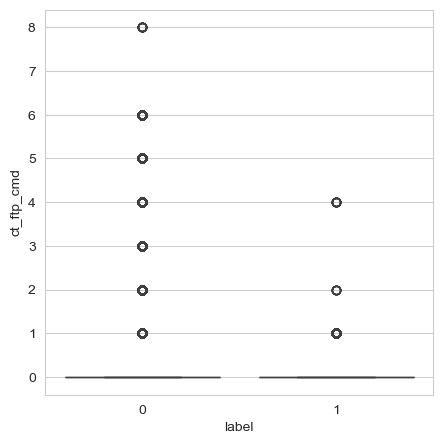

In [33]:
import seaborn as sns
plt.figure(figsize=(5,5))
sns.boxplot(x='label', y='ct_ftp_cmd', data=df)

In [61]:
print(df['is_ftp_login'].value_counts())

is_ftp_login
0.0    1066593
1.0      43389
4.0        156
2.0         30
Name: count, dtype: int64


In [53]:
print(df['ct_flw_http_mthd'].fillna(0).value_counts())

ct_flw_http_mthd
0.0     2334936
1.0      188008
6.0        7902
4.0        6564
3.0         738
2.0         588
5.0         430
9.0         270
14.0        224
12.0        132
30.0         60
8.0          56
16.0         48
36.0         36
10.0         30
25.0         25
Name: count, dtype: int64


In [59]:
df["label"] = df["label"].fillna(0).astype(int)

df['is_dos'] = (df['attack_cat'].fillna('').str.lower() == 'dos').astype(int)

correlation = df['ct_flw_http_mthd'].corr(df['is_dos'], method='spearman')

print(f"Spearman Correlation between 'ct_flw_http_mthd' and 'DoS': {correlation:.4f}")

analysis = df.groupby('is_dos')['ct_flw_http_mthd'].agg(['mean', 'max', 'std', 'count'])

display(analysis)

Spearman Correlation between 'ct_flw_http_mthd' and 'DoS': 0.0526


,mean,max,std,count
is_dos,,,,
0,0.233640,36.0,0.794039,1189272
1,0.662357,6.0,0.696722,2630


In [47]:
df["attack_cat"].unique()

<StringArray>
[              <NA>,         'Exploits',   'Reconnaissance',
              'DoS',          'Generic',        'Shellcode',
         ' Fuzzers',            'Worms',        'Backdoors',
         'Analysis', ' Reconnaissance ',         'Backdoor',
        ' Fuzzers ',      ' Shellcode ']
Length: 14, dtype: string

### 3) Cleaning + minimal feature selection

We keep this step simple and explainable:
- Remove duplicate rows
- Fix missing `attack_cat` for normal traffic (treat as **`Normal`**)
- Drop ID-like / leakage-prone columns (IP addresses, raw timestamps)
- Drop zero-variance numeric features
- Drop one of each pair of highly-correlated numeric features (to reduce redundancy)


In [63]:
dropped_features = []  # list[dict]

def drop_cols(cols, reason: str):
    global df
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return
    df = df.drop(columns=cols)
    dropped_features.append({"columns": cols, "reason": reason})

# 1) Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped duplicates: {before - len(df):,}")

# 2) Fix attack_cat for normal traffic & Clean labels
df["attack_cat"] = df["attack_cat"].astype("string")
df.loc[df["label"].fillna(0).astype(int) == 0, "attack_cat"] = df.loc[
    df["label"].fillna(0).astype(int) == 0, "attack_cat"
    ].fillna("Normal")

# Clean whitespace and standardize names
df["attack_cat"] = df["attack_cat"].str.strip()
# Merge obvious duplicates (e.g. plural vs singular)
df["attack_cat"] = df["attack_cat"].replace({
    "Backdoors": "Backdoor",
})
# Fill any remaining unknowns
df["attack_cat"] = df["attack_cat"].fillna("Unknown")

# 3) Drop ID-like columns (high-cardinality identifiers) and raw timestamps
# Rationale: they are often non-generalizable identifiers (e.g., specific IPs) and can cause leakage.
drop_cols(["srcip", "dstip"], "Identifier-like (IP address); high-cardinality and weakly generalizable")
drop_cols(["stime", "ltime"], "Raw timestamps; can cause leakage and are not stable across environments")


drop_cols(['ct_ftp_cmd'],"Specific to FTP protocol with low coverage across the full dataset")
drop_cols(["ct_flw_http_mthd"], "Sparse HTTP-specific metric; redundant if 'service' or 'is_http_login' is present")
drop_cols(["is_ftp_login"], "Sparse binary indicator; provides redundant information already captured by 'service' or 'proto'")
# Targets
TARGET_LABEL = "label"
TARGET_ATTACK = "attack_cat"

# Candidate feature columns
feature_cols = [c for c in df.columns if c not in {TARGET_LABEL, TARGET_ATTACK}]

# 4) Drop zero-variance numeric features
numeric_features = [c for c in feature_cols if type_map.get(c) == "numeric"]
var = df[numeric_features].var(skipna=True)
zero_var = var[var <= 1e-12].index.tolist()
drop_cols(zero_var, "Zero (or near-zero) variance")

# Refresh after drops
feature_cols = [c for c in df.columns if c not in {TARGET_LABEL, TARGET_ATTACK}]
numeric_features = [c for c in feature_cols if type_map.get(c) == "numeric"]

# 5) Correlation filter on numeric features
# Compute on a sample for speed; this is a lightweight redundancy check.
corr_sample = df[numeric_features].sample(n=min(100_000, len(df)), random_state=RANDOM_STATE)
corr = corr_sample.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.95)]
drop_cols(high_corr_cols, "Highly correlated numeric feature (|corr| > 0.95) — reduce redundancy")

# Final feature list
feature_cols = [c for c in df.columns if c not in {TARGET_LABEL, TARGET_ATTACK}]

print("\nFinal dataset shape:", df.shape)
print("Final feature count:", len(feature_cols))
print("Dropped feature groups:")
display(pd.DataFrame(dropped_features))

Dropped duplicates: 480,633

Final dataset shape: (2059414, 39)
Final feature count: 37
Dropped feature groups:


,columns,reason
0,"[srcip, dstip]",Identifier-like (IP address); high-cardinality...
1,"[stime, ltime]",Raw timestamps; can cause leakage and are not ...
2,[ct_ftp_cmd],Specific to FTP protocol with low coverage acr...
3,[ct_flw_http_mthd],Sparse HTTP-specific metric; redundant if 'ser...
4,[is_ftp_login],Sparse binary indicator; provides redundant in...
5,"[sloss, dloss, dpkts, dwin]",Highly correlated numeric feature (|corr| > 0....


In [67]:
from sklearn.utils import resample

print("\nOriginal attack distribution (counts):")
display(df[TARGET_ATTACK].value_counts().to_frame("count"))

print("\nOriginal attack distribution (fraction):")
display(df[TARGET_ATTACK].value_counts(normalize=True).to_frame("fraction"))


normal_df = df[df[TARGET_ATTACK] == "Normal"]
attack_df = df[df[TARGET_ATTACK] != "Normal"]

print("\nNormal samples:", len(normal_df))
print("Attack samples:", len(attack_df))

attack_counts = attack_df[TARGET_ATTACK].value_counts()
max_attack_size = attack_counts.max()

print("\nLargest attack class size:", max_attack_size)

oversampled_attacks = []

for attack_type, group in attack_df.groupby(TARGET_ATTACK):

    oversampled = resample(
        group,
        replace=True,
        n_samples=max_attack_size,
        random_state=RANDOM_STATE
    )

    oversampled_attacks.append(oversampled)

balanced_attack_df = pd.concat(oversampled_attacks)

balanced_df = pd.concat([normal_df, balanced_attack_df])

balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE)

print("\nBalanced dataset shape:", balanced_df.shape)

print("\nBalanced label distribution:")
display(balanced_df[TARGET_LABEL].value_counts(normalize=True).to_frame("fraction"))

print("\nBalanced attack_cat distribution:")
display(balanced_df[TARGET_ATTACK].value_counts().to_frame("count"))

print("\nBalanced attack_cat distribution (fraction):")
display(balanced_df[TARGET_ATTACK].value_counts(normalize=True).to_frame("fraction"))


Original attack distribution (counts):


,count
attack_cat,
Normal,1959771
Exploits,27599
Generic,25378
Fuzzers,21795
Reconnaissance,13357
DoS,5665
Analysis,2184
Backdoor,1983
Shellcode,1511



Original attack distribution (fraction):


,fraction
attack_cat,
Normal,0.951616
Exploits,0.013401
Generic,0.012323
Fuzzers,0.010583
Reconnaissance,0.006486
DoS,0.002751
Analysis,0.00106
Backdoor,0.000963
Shellcode,0.000734



Normal samples: 1959771
Attack samples: 99643

Largest attack class size: 27599

Balanced dataset shape: (2208162, 39)

Balanced label distribution:


,fraction
label,
0,0.887512
1,0.112488



Balanced attack_cat distribution:


,count
attack_cat,
Normal,1959771
Fuzzers,27599
DoS,27599
Backdoor,27599
Exploits,27599
Worms,27599
Generic,27599
Shellcode,27599
Reconnaissance,27599



Balanced attack_cat distribution (fraction):


,fraction
attack_cat,
Normal,0.887512
Fuzzers,0.012499
DoS,0.012499
Backdoor,0.012499
Exploits,0.012499
Worms,0.012499
Generic,0.012499
Shellcode,0.012499
Reconnaissance,0.012499


### 4) Modeling approach

We will train **two separate classifiers**:
- One for **`label`** (binary)
- One for **`attack_cat`** (multi-class)

To keep things practical and beginner-friendly:
- We use a single **preprocessing pipeline** (simple imputation + categorical encoding)
- We compare **two robust model families** (Random Forest vs Gradient Boosting)
- We apply **hyperparameter tuning** with a small random search
- We handle imbalance using **`class_weight='balanced'`** (RF) or **sample weights** (boosting)


In [71]:
numeric_features = [c for c in feature_cols if type_map.get(c) == "numeric"]
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Ordinal encoding keeps the feature space compact (important for large datasets)
try:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
except TypeError:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def tune_compare_and_evaluate(
    X,
    y,
    task_name: str,
    scoring: str,
    is_multiclass: bool,
    out_model_path: Path,
):
    # Split once so both models compare on the same holdout set
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Model 1: Random Forest (handles imbalance via class_weight)
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    )
    rf_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", rf)])

    rf_params = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 20, 40],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5],
    }

    rf_search = RandomizedSearchCV(
        rf_pipe,
        rf_params,
        n_iter=10,
        scoring=scoring,
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    # Model 2: Gradient Boosting (HistGradientBoostingClassifier)
    hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    hgb_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", hgb)])

    hgb_params = {
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [None, 10],
        "model__max_iter": [200, 400],
        "model__max_leaf_nodes": [31, 63],
        "model__l2_regularization": [0.0, 1.0],
    }

    hgb_search = RandomizedSearchCV(
        hgb_pipe,
        hgb_params,
        n_iter=10,
        scoring=scoring,
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    # Sample weights for imbalance (works well for boosting)
    sw = compute_sample_weight(class_weight="balanced", y=y_train)

    print(f"\n=== {task_name}: tuning Random Forest ===")
    rf_search.fit(X_train, y_train)

    print(f"\n=== {task_name}: tuning Gradient Boosting ===")
    hgb_search.fit(X_train, y_train, model__sample_weight=sw)

    results = pd.DataFrame(
        {
            "model": ["RandomForest", "HistGradientBoosting"],
            "best_cv_score": [rf_search.best_score_, hgb_search.best_score_],
        }
    ).sort_values("best_cv_score", ascending=False)

    print("\nBest CV results:")
    display(results)

    # Select by CV score (keeps the test set purely for reporting)
    best_search = rf_search if rf_search.best_score_ >= hgb_search.best_score_ else hgb_search
    best_name = "RandomForest" if best_search is rf_search else "HistGradientBoosting"

    print(f"\nSelected best model for {task_name}: {best_name}")

    # Evaluate both models on the same test set for transparency
    for name, search in [("RandomForest", rf_search), ("HistGradientBoosting", hgb_search)]:
        y_pred = search.best_estimator_.predict(X_test)
        print(f"\n--- {task_name} | {name} | Test metrics ---")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred, digits=4))
        plot_confusion(y_test, y_pred, title=f"{task_name} — Confusion matrix ({name})")

    # Save the selected best pipeline
    joblib.dump(best_search.best_estimator_, out_model_path)
    print("Saved model to:", out_model_path)

    return {
        "best_model_name": best_name,
        "best_cv_score": best_search.best_score_,
        "best_estimator": best_search.best_estimator_,
    }

Numeric features: 33
Categorical features: 4


### 5) Task A — Binary classification (`label`)

We compare/tune two models and select the best based on **cross-validation F1 score** (then report final test-set results).


In [73]:
# Redefine confusion-matrix plotting with readable labels (especially for multiclass)
def plot_confusion(y_true, y_pred, title: str, labels=None):
    if labels is None:
        labels = pd.Index(y_true).append(pd.Index(y_pred)).unique().tolist()
        # Keep a stable, readable ordering
        try:
            labels = sorted(labels)
        except TypeError:
            labels = [str(x) for x in labels]
            labels = sorted(labels)

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=False if cm.shape[0] > 15 else True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


### 4b) Save the processed dataset (reusable)

We save a single processed CSV that includes:
- All selected feature columns
- Both targets (`label`, `attack_cat`)

We also save small metadata files (feature list + dropped features) so it’s easy to reload consistently later.


In [75]:
processed_path = OUT_DIR / "UNSW_NB15_processed.csv"
features_path_out = OUT_DIR / "selected_features.json"
dropped_path_out = OUT_DIR / "dropped_features.json"

processed_df = df[feature_cols + [TARGET_LABEL, TARGET_ATTACK]].copy()
processed_df.to_csv(processed_path, index=False)

features_path_out.write_text(json.dumps(feature_cols, indent=2))
dropped_path_out.write_text(json.dumps(dropped_features, indent=2))

print("Saved processed dataset:", processed_path)
print("Saved selected feature list:", features_path_out)
print("Saved dropped feature log:", dropped_path_out)
print("Processed shape:", processed_df.shape)
processed_df.head()


Saved processed dataset: Processed_Dataset\UNSW_NB15_processed.csv
Saved selected feature list: Processed_Dataset\selected_features.json
Saved dropped feature log: Processed_Dataset\dropped_features.json
Processed shape: (2059414, 39)


,sport,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,service,...,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_dos,label,attack_cat
0,1390.0,53.0,udp,CON,0.001055,132,164,31,29,dns,...,3,7,1,3,1,1,1,0,0,Normal
1,33661.0,1024.0,udp,CON,0.036133,528,304,31,29,-,...,2,4,2,3,1,1,2,0,0,Normal
2,1464.0,53.0,udp,CON,0.001119,146,178,31,29,dns,...,12,8,1,2,2,1,1,0,0,Normal
3,3593.0,53.0,udp,CON,0.001209,132,164,31,29,dns,...,6,9,1,1,1,1,1,0,0,Normal
4,49664.0,53.0,udp,CON,0.001169,146,178,31,29,dns,...,7,9,1,1,1,1,1,0,0,Normal


In [79]:
# Train / test features for modeling
X = balanced_df[feature_cols]   
y_label = balanced_df[TARGET_LABEL]
y_attack = balanced_df[TARGET_ATTACK]

print("X shape:", X.shape)
print("y_label classes:", sorted(y_label.unique().tolist()))
print("y_attack classes (count):", y_attack.nunique())
print("y_attack examples:", y_attack.value_counts().head(10).to_dict())


X shape: (2208162, 37)
y_label classes: [0, 1]
y_attack classes (count): 10
y_attack examples: {'Normal': 1959771, 'Fuzzers': 27599, 'DoS': 27599, 'Backdoor': 27599, 'Exploits': 27599, 'Worms': 27599, 'Generic': 27599, 'Shellcode': 27599, 'Reconnaissance': 27599, 'Analysis': 27599}


In [ ]:
# Task A: binary classification
label_model_path = OUT_DIR / "model_label_best.joblib"
label_summary_path = OUT_DIR / "model_label_summary.json"

label_result = tune_compare_and_evaluate(
    X=X,
    y=y_label,
    task_name="Task A — label (binary)",
    scoring="f1_weighted",
    is_multiclass=False,
    out_model_path=label_model_path,
)

label_summary_path.write_text(
    json.dumps(
        {
            "task": "label",
            "selected_model": label_result["best_model_name"],
            "best_cv_score": label_result["best_cv_score"],
            "features": feature_cols,
        },
        indent=2,
    )  
)
print("Saved summary to:", label_summary_path)


=== Task A — label (binary): tuning Random Forest ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits



=== Task B — attack_cat (multi-class): tuning Random Forest ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== Task B — attack_cat (multi-class): tuning Gradient Boosting ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV results:


,model,best_cv_score
0,RandomForest,0.982779
1,HistGradientBoosting,0.980056



Selected best model for Task B — attack_cat (multi-class): RandomForest

--- Task B — attack_cat (multi-class) | RandomForest | Test metrics ---
Accuracy: 0.98204
                precision    recall  f1-score   support

      Analysis     0.0876    0.2075    0.1232       106
      Backdoor     0.1198    0.3021    0.1716        96
           DoS     0.3432    0.2945    0.3170       275
      Exploits     0.8167    0.8343    0.8254      1340
       Fuzzers     0.5545    0.7932    0.6527      1059
       Generic     0.9735    0.8661    0.9167      1232
        Normal     0.9984    0.9924    0.9954     95162
Reconnaissance     0.8907    0.8290    0.8587       649
     Shellcode     0.7816    0.9315    0.8500        73
         Worms     0.5000    0.7500    0.6000         8

      accuracy                         0.9820    100000
     macro avg     0.6066    0.6801    0.6311    100000
  weighted avg     0.9864    0.9820    0.9839    100000



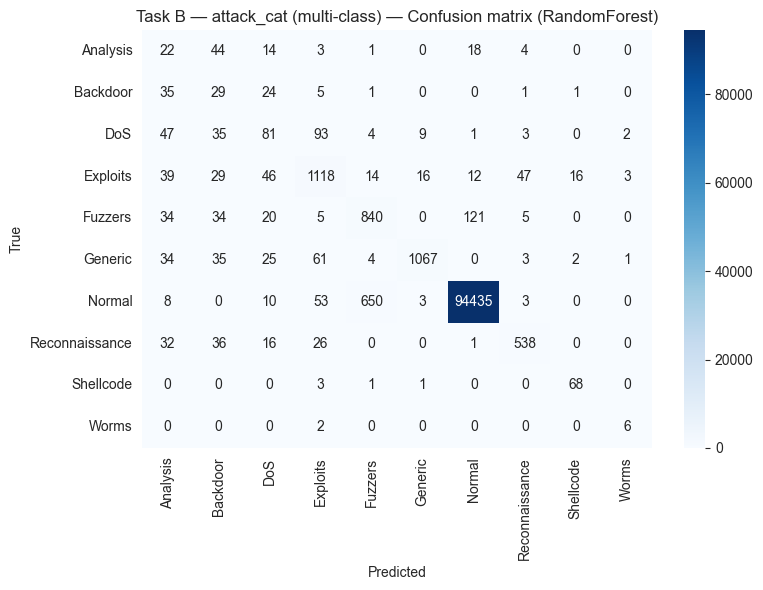


--- Task B — attack_cat (multi-class) | HistGradientBoosting | Test metrics ---
Accuracy: 0.97662
                precision    recall  f1-score   support

      Analysis     0.1124    0.4623    0.1808       106
      Backdoor     0.1238    0.2708    0.1699        96
           DoS     0.3275    0.3418    0.3345       275
      Exploits     0.8203    0.7664    0.7924      1340
       Fuzzers     0.4460    0.9056    0.5977      1059
       Generic     0.9634    0.8750    0.9171      1232
        Normal     0.9999    0.9859    0.9928     95162
Reconnaissance     0.8782    0.8336    0.8553       649
     Shellcode     0.7253    0.9041    0.8049        73
         Worms     0.5556    0.6250    0.5882         8

      accuracy                         0.9766    100000
     macro avg     0.5952    0.6970    0.6234    100000
  weighted avg     0.9865    0.9766    0.9805    100000



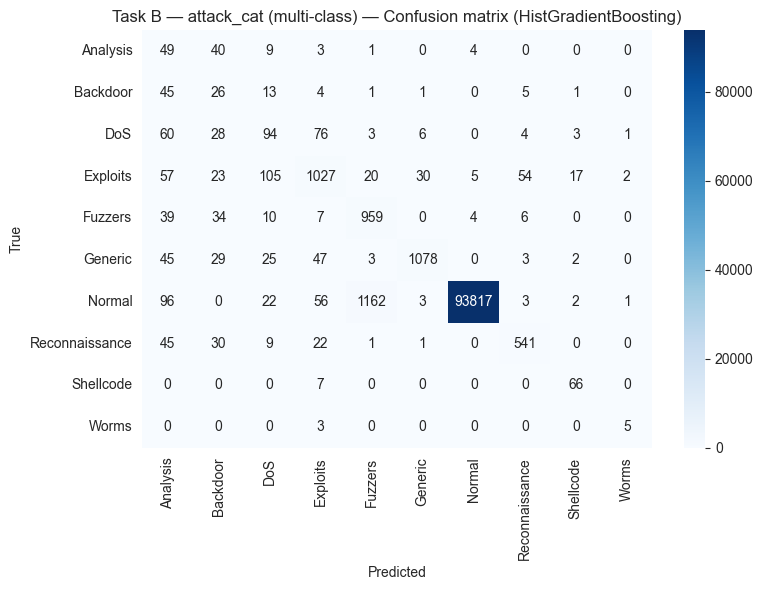

Saved model to: Processed_Dataset\model_attack_cat_best.joblib
Saved summary to: Processed_Dataset\model_attack_cat_summary.json


In [ ]:
# Task B: multi-class classification
attack_model_path = OUT_DIR / "model_attack_cat_best.joblib"
attack_summary_path = OUT_DIR / "model_attack_cat_summary.json"

attack_result = tune_compare_and_evaluate(
    X=X,
    y=y_attack,
    task_name="Task B — attack_cat (multi-class)",
    scoring="f1_weighted",
    is_multiclass=True,
    out_model_path=attack_model_path,
)

attack_summary_path.write_text(
    json.dumps(
        {
            "task": "attack_cat",
            "selected_model": attack_result["best_model_name"],
            "best_cv_score": attack_result["best_cv_score"],
            "classes": sorted(y_attack.unique().tolist()),
            "features": feature_cols,
        },
        indent=2,
    )
)
print("Saved summary to:", attack_summary_path)

### 6) Outputs recap

After running the notebook, you should have these artifacts in `training/Processed_Dataset/`:
- `UNSW_NB15_processed.csv` (cleaned + selected features + both targets)
- `selected_features.json`
- `dropped_features.json`
- `model_label_best.joblib` + `model_label_summary.json`
- `model_attack_cat_best.joblib` + `model_attack_cat_summary.json`

If you want faster runs, reduce `MAX_ROWS_FOR_MODELING` near the top.
